In [1]:
import numpy as np
import pandas as pd
import joblib

from string import ascii_lowercase
from matplotlib import pyplot as plt


In [2]:
plt.style.use('ggplot')

In [3]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [3]:
btl_client_list_df = pd.read_csv("june_data/AGOST_June2025.csv", sep=",")
btl_due_oil_pms_df = pd.read_csv("june_data/Other_Customers_June2025_DueOil_or_DuePMS.csv", sep=",")
btl_non_due_cli_df = pd.read_csv("june_data/Other_Customers_June2025_notDueOil_and_PMS.csv", sep=",")
btl_gone_client_df = pd.read_csv("june_data/zero_PMS_Oil_Due_Gone_Customers_June2025.csv", sep=",")
btl_lost_client_df = pd.read_csv("june_data/zero_PMS_Oil_Due_Lost_Customers_June2025.csv", sep=",")

In [4]:
display(btl_client_list_df.head(2))
display(btl_due_oil_pms_df.head(2))
display(btl_non_due_cli_df.head(2))
display(btl_gone_client_df.head(2))
display(btl_lost_client_df.head(2))

,Mobile,PlateNumber,TotalVisits,TotalNetAmount,TotalOilVisits,TotalNetOilAmount,TotalPMSVisits,TotalNetPMSAmount,TotalPromoVisits,TotalNetPromoAmount,FirstVisitDate,LastVisitDate,FirstOdometer,LastOdometer,FirstVisitIsOil,LastVisitIsOil,FirstVisitIsPMS,LastVisitIsPMS,FirstVisitIsPromo,LastVisitIsPromo,LastMobileDigit,Make,Model,Nationality,City,PreferredLanguage,Segment,IsChinesePMS,IsPromoHunter,LastPromoTaken,IsLastVehicleUsed,IsDueOil,IsDuePMS,IsDueAirFilter,IsDueCabinFilter,IsDueTyres,IsDueBattery,IsDueBrakes,IsDueEngineFlush,IsDueSuspension,IsDueACServices,IsDueACRepair,IsDueHeadlightPolish,InvCounts12mos,InvPromoCounts12mos,DueDate
0,500000000,0044EDX,1,126.087,0,0.00,0,0.0,0,0.0,2022-05-19,2022-05-19,50000,50000,0,0,0,0,0,0,0,GMC,SIERRA 1500 CLASSIC,Saudi,RIYADH,AR,Gone Customers,0,0,NaN,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,NaN
1,500000000,0044RSG,1,164.790,1,164.79,0,0.0,0,0.0,2024-05-21,2024-05-21,266779,266779,1,1,0,0,0,0,0,JEEP,GRAND CHEROKEE,NaN,JEDDAH,AR,Outliers,0,0,NaN,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,NaN


,Mobile,PlateNumber,TotalVisits,TotalNetAmount,TotalOilVisits,TotalNetOilAmount,TotalPMSVisits,TotalNetPMSAmount,TotalPromoVisits,TotalNetPromoAmount,FirstVisitDate,LastVisitDate,FirstOdometer,LastOdometer,FirstVisitIsOil,LastVisitIsOil,FirstVisitIsPMS,LastVisitIsPMS,FirstVisitIsPromo,LastVisitIsPromo,LastMobileDigit,Make,Model,Nationality,City,PreferredLanguage,Segment,IsChinesePMS,IsPromoHunter,LastPromoTaken,IsLastVehicleUsed,IsDueOil,IsDuePMS,IsDueAirFilter,IsDueCabinFilter,IsDueTyres,IsDueBattery,IsDueBrakes,IsDueEngineFlush,IsDueSuspension,IsDueACServices,IsDueACRepair,IsDueHeadlightPolish,InvCounts12mos,InvPromoCounts12mos,DueDate
0,500000000,0061ZDN,1,86.090,0,0.0,0,0.0,0,0.0,7/17/2024,7/17/2024,593685,593685,0,0,0,0,0,0,0,TOYOTA,CAMRY,Saudi,RIYADH,AR,Outliers,0,0,NaN,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,NaN
1,500000000,0535DAZ,2,216.517,0,0.0,0,0.0,0,0.0,7/30/2023,8/20/2024,383055,383055,0,0,0,0,0,0,0,NISSAN,PATHFINDER,Saudi,RIYADH,AR,Outliers,0,0,NaN,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,NaN


,Row Labels,Count of PlateNumber
0,"IsDueTyres, IsDueBattery",748456
1,IsDueTyres,56752


,Mobile,PlateNumber,TotalVisits,TotalNetAmount,TotalOilVisits,TotalNetOilAmount,TotalPMSVisits,TotalNetPMSAmount,TotalPromoVisits,TotalNetPromoAmount,FirstVisitDate,LastVisitDate,FirstOdometer,LastOdometer,FirstVisitIsOil,LastVisitIsOil,FirstVisitIsPMS,LastVisitIsPMS,FirstVisitIsPromo,LastVisitIsPromo,LastMobileDigit,Make,Model,Nationality,City,PreferredLanguage,Segment,IsChinesePMS,IsPromoHunter,LastPromoTaken,IsLastVehicleUsed,IsDueOil,IsDuePMS,IsDueAirFilter,IsDueCabinFilter,IsDueTyres,IsDueBattery,IsDueBrakes,IsDueEngineFlush,IsDueSuspension,IsDueACServices,IsDueACRepair,IsDueHeadlightPolish,InvCounts12mos,InvPromoCounts12mos,DueDate,Oil or PMS Due
0,500000000,0484UNU,1,143.4782,1,143.4782,0,0.0,0,0.0000,2021-04-20,2021-04-20,200000,200000,1,1,0,0,0,0,0,CHEVROLET,Suburban,Saudi,JEDDAH,AR,Gone Customers,0,0,NaN,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,NaN,0
1,500000000,0778ASU,1,51.3043,1,51.3043,0,0.0,1,51.3043,2021-09-22,2021-09-22,472252,472252,1,1,0,0,1,1,0,TOYOTA,COROLLA,Saudi,MAKKAH,AR,Gone Customers,0,1,National Day Promo - Mineral Oil - SAR 59 Package,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,NaN,0


,Mobile,PlateNumber,TotalVisits,TotalNetAmount,TotalOilVisits,TotalNetOilAmount,TotalPMSVisits,TotalNetPMSAmount,TotalPromoVisits,TotalNetPromoAmount,FirstVisitDate,LastVisitDate,FirstOdometer,LastOdometer,FirstVisitIsOil,LastVisitIsOil,FirstVisitIsPMS,LastVisitIsPMS,FirstVisitIsPromo,LastVisitIsPromo,LastMobileDigit,Make,Model,Nationality,City,PreferredLanguage,Segment,IsChinesePMS,IsPromoHunter,LastPromoTaken,IsLastVehicleUsed,IsDueOil,IsDuePMS,IsDueAirFilter,IsDueCabinFilter,IsDueTyres,IsDueBattery,IsDueBrakes,IsDueEngineFlush,IsDueSuspension,IsDueACServices,IsDueACRepair,IsDueHeadlightPolish,InvCounts12mos,InvPromoCounts12mos,DueDate,Oil or PMS Due
0,500000000,2000XGB,1,134.7826,1,134.7826,0,0.0,0,0.0,2024-01-06,2024-01-06,185528,185528,1,1,0,0,0,0,0,LEXUS,RX350,Saudi,JEDDAH,AR,Lost Customers,0,0,NaN,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,NaN,0
1,500000000,2540DRJ,1,134.7826,1,134.7826,0,0.0,0,0.0,2024-01-07,2024-01-07,340801,340801,1,1,0,0,0,0,0,FORD,TAURUS,Saudi,TAIF,AR,Lost Customers,0,0,NaN,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,NaN,0


In [ ]:
filter_non_due = (btl_due_oil_pms_df["IsDueOil"] == 0) & (btl_due_oil_pms_df["IsDuePMS"] == 0)
btl_due_oil_pms_df[filter_non_due].shape

(0, 46)

In [58]:
btl_client_list_df["PlateNumber"].apply(len).value_counts()

PlateNumber
7    2632427
Name: count, dtype: int64

In [62]:
btl_client_list_df["Mobile"] = btl_client_list_df["Mobile"].astype(str)
btl_client_list_df["Mobile"] = btl_client_list_df["Mobile"].str.zfill(10)

### Filter wrong mobile and plate numbers

In [17]:
wrong_plates = [
    f"{number}"*4 + f"{letter.upper()}"*3 
    for letter in ascii_lowercase 
    for number in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
]

wrong_mobiles = [
    f"0{number1}" + f"{number2}"*7 + f"{number3}"
    for number1 in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    for number2 in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    for number3 in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
]

In [18]:
wrong_mobiles

['0000000000',
 '0000000001',
 '0000000002',
 '0000000003',
 '0000000004',
 '0000000005',
 '0000000006',
 '0000000007',
 '0000000008',
 '0000000009',
 '0011111110',
 '0011111111',
 '0011111112',
 '0011111113',
 '0011111114',
 '0011111115',
 '0011111116',
 '0011111117',
 '0011111118',
 '0011111119',
 '0022222220',
 '0022222221',
 '0022222222',
 '0022222223',
 '0022222224',
 '0022222225',
 '0022222226',
 '0022222227',
 '0022222228',
 '0022222229',
 '0033333330',
 '0033333331',
 '0033333332',
 '0033333333',
 '0033333334',
 '0033333335',
 '0033333336',
 '0033333337',
 '0033333338',
 '0033333339',
 '0044444440',
 '0044444441',
 '0044444442',
 '0044444443',
 '0044444444',
 '0044444445',
 '0044444446',
 '0044444447',
 '0044444448',
 '0044444449',
 '0055555550',
 '0055555551',
 '0055555552',
 '0055555553',
 '0055555554',
 '0055555555',
 '0055555556',
 '0055555557',
 '0055555558',
 '0055555559',
 '0066666660',
 '0066666661',
 '0066666662',
 '0066666663',
 '0066666664',
 '0066666665',
 '00666666

In [19]:
filter_mobile = ~btl_client_list_df["Mobile"].isin(wrong_mobiles)
filter_plates = ~btl_client_list_df["PlateNumber"].isin(wrong_plates)
filters = filter_mobile & filter_plates

btl_client_list_df.shape, btl_client_list_df[filter_mobile].shape, btl_client_list_df[filter_plates].shape, btl_client_list_df[filters].shape

((2632427, 46), (2629058, 46), (2632343, 46), (2628984, 46))

In [53]:
btl_client_list_df[filters].head(5)

,Mobile,PlateNumber,TotalVisits,TotalNetAmount,TotalOilVisits,TotalNetOilAmount,TotalPMSVisits,TotalNetPMSAmount,TotalPromoVisits,TotalNetPromoAmount,FirstVisitDate,LastVisitDate,FirstOdometer,LastOdometer,FirstVisitIsOil,LastVisitIsOil,FirstVisitIsPMS,LastVisitIsPMS,FirstVisitIsPromo,LastVisitIsPromo,LastMobileDigit,Make,Model,Nationality,City,PreferredLanguage,Segment,IsChinesePMS,IsPromoHunter,LastPromoTaken,IsLastVehicleUsed,IsDueOil,IsDuePMS,IsDueAirFilter,IsDueCabinFilter,IsDueTyres,IsDueBattery,IsDueBrakes,IsDueEngineFlush,IsDueSuspension,IsDueACServices,IsDueACRepair,IsDueHeadlightPolish,InvCounts12mos,InvPromoCounts12mos,DueDate
206,0500000026,0020RZE,1,172.1739,1,172.1739,0,0.0000,1,172.1739,2021-09-23,2021-09-23,74633,74633,1,1,0,0,1,1,6,NISSAN,PATROL,Saudi,DAMMAM,AR,Gone Customers,0,1,National Day Promo - Synthetic Oil - SAR 139 P...,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,NaN
207,0500000034,8174SAD,4,1099.7565,3,892.1739,1,207.5826,0,0.0000,2021-12-08,2022-08-06,163726,184930,1,0,0,1,0,0,4,TOYOTA,Fj Cruiser,Saudi,KHAMIS,AR,Gone Customers,0,0,NaN,1,0,0,0,0,0,1,0,0,0,0,0,0,4,0,NaN
208,0500000042,1194TBD,5,538.3480,5,538.3480,0,0.0000,2,217.3914,2020-12-21,2023-12-25,130926,161000,1,1,0,0,1,0,2,KIA,OPTIMA,NaN,KHAMIS,AR,Lost Customers,0,0,NaN,1,0,0,0,0,0,1,0,0,0,0,0,0,5,2,NaN
209,0500000114,0005ULX,1,138.2609,1,138.2609,0,0.0000,1,138.2609,2020-12-31,2020-12-31,214175,214175,1,1,0,0,1,1,4,TOYOTA,Fortuner,Indian,RIYADH,EN,Gone Customers,0,1,Special Offer Mineral Silver Service,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,NaN
210,0500000114,8968UHD,2,1045.2174,2,1045.2174,0,0.0000,0,0.0000,2021-12-09,2022-04-26,126925,133881,1,1,0,0,0,0,4,CHEVROLET,Suburban,Saudi,RIYADH,AR,Gone Customers,0,0,NaN,1,0,0,0,0,0,1,0,0,0,0,0,0,2,0,NaN


# Read Database clients

In [38]:
customer_df = pd.read_parquet("../data/02_intermediate/int_customers")
vehicle_df = pd.read_parquet("../data/02_intermediate/int_vehicles")

In [39]:
customer_df["mobile"] = customer_df["mobile"].str.zfill(10)
# customer_df["mobile"] = customer_df["mobile"].str.slice_replace(stop=1, repl='966')

In [40]:
vehicle_df["plate_number"] = vehicle_df["plate_number"].str.zfill(7)

In [41]:
customer_vehicle_df = pd.merge(
    customer_df,
    vehicle_df,
    on="customer_id",
    how="outer"
)

In [42]:
mobile_btl_not_db = sorted(set(btl_client_list_df[filters]["Mobile"].values) - set(customer_vehicle_df["mobile"].values))
len(mobile_btl_not_db)

6755

In [43]:
plate_btl_not_db = sorted(set(btl_client_list_df[filters]["PlateNumber"].values) - set(customer_vehicle_df["plate_number"].values))
len(plate_btl_not_db)

7004

In [51]:
plate_mobile_btl_not_db = sorted(set(btl_client_list_df[filters][["Mobile", "PlateNumber"]].to_records(index=False).tolist()) - set(customer_vehicle_df[["mobile", "plate_number"]].to_records(index=False).tolist()))
len(plate_mobile_btl_not_db)

11664

In [59]:
customer_vehicle_df.shape, btl_client_list_df.shape

((7075451, 32), (2632427, 46))

In [ ]:
customer_vehicle_df.drop_duplicates().shape, btl_client_list_df.drop_duplicates().shape

((7075451, 32), (2632427, 46))

In [63]:
display(customer_vehicle_df[["mobile", "plate_number"]].head(2))
display(btl_client_list_df[["Mobile", "PlateNumber"]].head(2))

,mobile,plate_number
0,0552950555,6017DSA
1,0534747726,1065KHD


,Mobile,PlateNumber
0,0500000000,0044EDX
1,0500000000,0044RSG


In [64]:
btl_client_list_df_extended = pd.merge(
    btl_client_list_df,
    customer_vehicle_df,
    left_on=["PlateNumber", "Mobile"],
    right_on=["plate_number", "mobile"],
    how="left"
)

btl_client_list_df_extended.shape, btl_client_list_df_extended.drop_duplicates().shape

((2886945, 78), (2886945, 78))

In [68]:
btl_client_list_df_extended["plate_number"].dropna().shape[0] / btl_client_list_df_extended.shape[0]

0.9959503904646607

## Churn Predictions

In [4]:
btl_client_list_df = pd.read_csv("june_data/AGOST_June2025.csv", sep=",")

In [5]:
mdl_churn_predicted_df = pd.read_parquet("../data/07_model_output/churn/predict/mdl_churn_predicted")

In [6]:
mdl_churn_predicted_df[["plate_number", "mobile"]] = mdl_churn_predicted_df["_id"].str.rpartition("__")[[0,2]]

In [7]:
mdl_churn_predicted_df["mobile"] = mdl_churn_predicted_df["mobile"].str.slice(3)

In [8]:
display(btl_client_list_df[["Mobile", "PlateNumber"]].head(2))

,Mobile,PlateNumber
0,500000000,0044EDX
1,500000000,0044RSG


In [9]:
display(mdl_churn_predicted_df[["mobile", "plate_number"]].head(2))

,mobile,plate_number
0,561191005,0000AAB
1,561191005,0000AAB


In [8]:
btl_client_list_df["Mobile"] = btl_client_list_df["Mobile"].astype(str)

In [11]:
filter_date = mdl_churn_predicted_df["_observ_end_dt"].astype(str) == "2025-05-31"

In [12]:
btl_client_list_df_extended = pd.merge(
    btl_client_list_df,
    mdl_churn_predicted_df[filter_date][["_id", "_observ_end_dt", "plate_number", "mobile", "churn_probability"]],
    left_on=["PlateNumber", "Mobile"],
    right_on=["plate_number", "mobile"],
    how="left"
)

In [14]:
btl_client_list_df_extended.shape, btl_client_list_df_extended.drop_duplicates(subset=["plate_number", "mobile"]).shape, np.round(btl_client_list_df_extended["churn_probability"].dropna().shape[0] / btl_client_list_df_extended.shape[0])

((2632427, 51), (2508864, 51), 1.0)

In [15]:
btl_client_list_df_extended.to_csv("june_data/churn_output_20250630.csv", sep=";", index=False)

In [16]:
mdl_churn_predicted_df[filter_date][["_id", "_observ_end_dt", "plate_number", "mobile", "churn_probability"]].to_csv("june_data/churn_only_output_20250630.csv", sep=";", index=False)

In [17]:
filter_date = mdl_churn_predicted_df["_observ_end_dt"].astype(str).isin(["2025-01-31", "2025-02-28", "2025-03-31"])

mdl_churn_predicted_df[filter_date][["_id", "_observ_end_dt", "plate_number", "mobile", "target_churn_1", "churn_probability"]].to_csv("june_data/churn_only_output_202501-202503.csv", sep=";", index=False)

In [13]:
btl_client_list_df_extended["Segment"].value_counts()

Segment
Gone Customers           1097315
Lost Customers            469863
Uncommitted Customers     414848
Potential Loyal           205072
Loyal                     173233
Outliers                  166356
New Joiners               105740
Name: count, dtype: int64

In [ ]:
filter_oil = btl_client_list_df_extended["IsDueOil"] == 1
filter_pms = btl_client_list_df_extended["IsDuePMS"] == 1
filter_segment = ~btl_client_list_df_extended["Segment"].isin(["Gone Customers", "Lost Customers",])
filters = (filter_oil | filter_pms) & filter_segment
btl_client_list_df_filtered = btl_client_list_df_extended[filters]

In [19]:
btl_client_list_df_extended.columns

Index(['Mobile', 'PlateNumber', 'TotalVisits', 'TotalNetAmount', 'TotalOilVisits', 'TotalNetOilAmount', 'TotalPMSVisits', 'TotalNetPMSAmount', 'TotalPromoVisits', 'TotalNetPromoAmount', 'FirstVisitDate', 'LastVisitDate', 'FirstOdometer', 'LastOdometer', 'FirstVisitIsOil', 'LastVisitIsOil', 'FirstVisitIsPMS', 'LastVisitIsPMS', 'FirstVisitIsPromo', 'LastVisitIsPromo', 'LastMobileDigit', 'Make', 'Model', 'Nationality', 'City', 'PreferredLanguage', 'Segment', 'IsChinesePMS', 'IsPromoHunter', 'LastPromoTaken', 'IsLastVehicleUsed', 'IsDueOil', 'IsDuePMS', 'IsDueAirFilter', 'IsDueCabinFilter', 'IsDueTyres', 'IsDueBattery', 'IsDueBrakes', 'IsDueEngineFlush', 'IsDueSuspension', 'IsDueACServices', 'IsDueACRepair', 'IsDueHeadlightPolish', 'InvCounts12mos', 'InvPromoCounts12mos', 'DueDate', '_id', '_observ_end_dt', 'plate_number', 'mobile', 'churn_probability'], dtype='object')

In [15]:
btl_client_list_df_filtered.shape, btl_client_list_df_extended.shape

((234475, 51), (2632427, 51))

## Full Campaign

In [18]:
btl_client_list_df_extended["churn_rank"] = pd.qcut(btl_client_list_df_extended["churn_probability"].round(2), q=10, labels=False, duplicates='drop')
btl_client_list_df_extended.groupby("churn_rank").agg({
    "churn_probability": ["min", "max", "count"]
})

churn_probability                  
                         min       max   count
churn_rank                                    
0.0                 0.000305  0.554999  269873
1.0                 0.555001  0.705000  243042
2.0                 0.705000  0.775000  588213
3.0                 0.775002  0.795000  182916
4.0                 0.795000  0.825000  260918
5.0                 0.825000  0.835000  716184
6.0                 0.835001  0.978858  247717

## Filtered Campaign

In [16]:
btl_client_list_df_filtered["churn_rank"] = pd.qcut(btl_client_list_df_filtered["churn_probability"], q=10, labels=False,)
btl_client_list_df_filtered.groupby("churn_rank").agg({
    "churn_probability": ["min", "max", "count"]
})

/var/folders/3r/sqxygt_d4gs0bc8yhzxh19vw0000gp/T/ipykernel_77044/142488378.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  btl_client_list_df_filtered["churn_rank"] = pd.qcut(btl_client_list_df_filtered["churn_probability"], q=10, labels=False,)


churn_probability                 
                         min       max  count
churn_rank                                   
0.0                 0.000747  0.481252  22041
1.0                 0.481262  0.587452  22041
2.0                 0.587455  0.620436  32402
3.0                 0.620438  0.638172  12047
4.0                 0.638182  0.667197  21954
5.0                 0.667201  0.712866  21759
6.0                 0.712889  0.778151  22041
7.0                 0.778161  0.814572  23257
8.0                 0.814575  0.840755  20824
9.0                 0.840755  0.960263  22041

<Axes: >

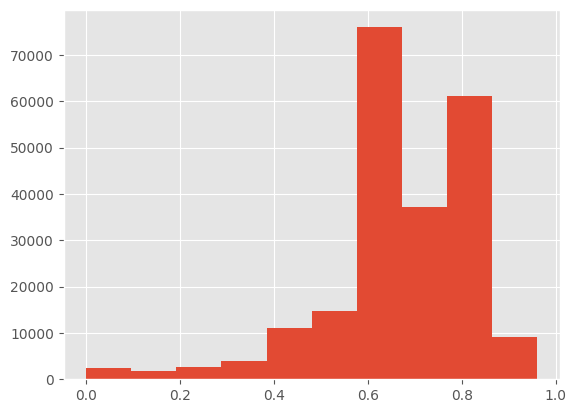

In [17]:
btl_client_list_df_filtered["churn_probability"].hist()

<Axes: xlabel='churn_probability'>

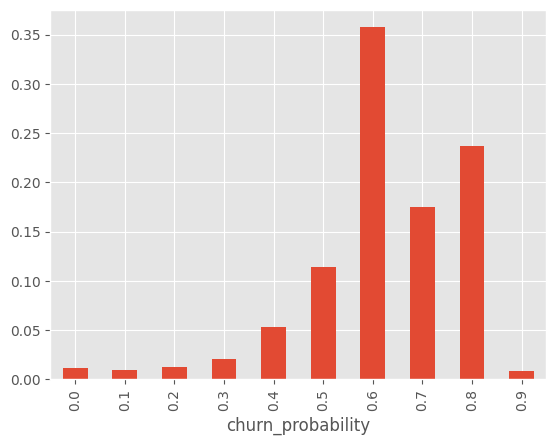

In [18]:
pd.cut(
    btl_client_list_df_filtered["churn_probability"],
    bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    labels=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
).value_counts(normalize=True).sort_index().plot(kind="bar")

# Check for only similar state as training

In [34]:
filter_date = mdl_churn_predicted_df["_observ_end_dt"].astype(str).isin(["2025-01-31", "2025-02-28", "2025-03-31", "2025-04-30"])
filter_acc_churn = mdl_churn_predicted_df["acc_churn_past_2_next_0_months"] < 2
filter_active_last_year = mdl_churn_predicted_df["is_active_sum_past_11_next_0_months"] > 1

training_filters = filter_date & filter_acc_churn & filter_active_last_year

In [35]:
 mdl_churn_predicted_df[training_filters].shape

(1553105, 537)

In [36]:
btl_client_list_df_training = pd.merge(
    btl_client_list_df,
    mdl_churn_predicted_df[training_filters][["_id", "_observ_end_dt", "plate_number", "mobile", "churn_probability"]],
    left_on=["PlateNumber", "Mobile"],
    right_on=["plate_number", "mobile"],
    how="left"
)

In [37]:
btl_client_list_df_training["churn_probability"].isna().sum()

2207147

<Axes: xlabel='churn_probability'>

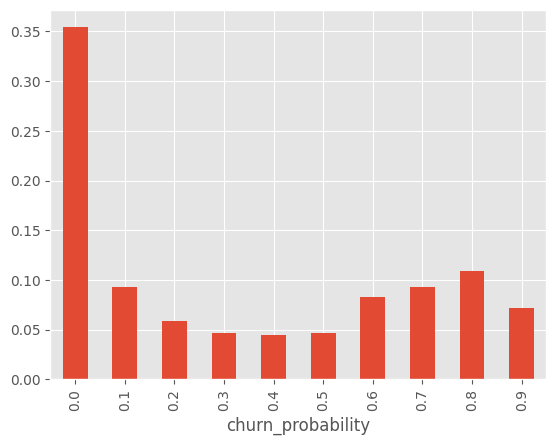

In [38]:
pd.cut(
    btl_client_list_df_training["churn_probability"].fillna(-1),
    bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    labels=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
).value_counts(normalize=True).sort_index().plot(kind="bar")

# Metrics by Segment

In [9]:
filter_date = mdl_churn_predicted_df["_observ_end_dt"].astype(str).isin(["2024-12-31", "2025-01-31", "2025-02-28", "2025-03-31", "2025-04-30"])
filter_acc_churn = mdl_churn_predicted_df["acc_churn_past_2_next_0_months"] < 2
filter_active_last_year = mdl_churn_predicted_df["is_active_sum_past_11_next_0_months"] > 1

training_filters = filter_date # & filter_acc_churn & filter_active_last_year

In [10]:
mdl_churn_predicted_df[training_filters].shape

(15239984, 550)

In [11]:
btl_client_list_df["Mobile"] = btl_client_list_df["Mobile"].astype(str)

In [12]:
btl_client_list_df_training = pd.merge(
    btl_client_list_df,
    mdl_churn_predicted_df[training_filters][["_id", "_observ_end_dt", "plate_number", "mobile", "target_churn_1", "churn_probability", "is_new_joiner", "is_uncommited", "is_potential_loyal", "is_loyal", "is_lost", "is_gone"]],
    left_on=["PlateNumber", "Mobile"],
    right_on=["plate_number", "mobile"],
    how="left"
)

In [13]:
btl_client_list_df_training["churn_probability"].isna().sum()

123860

In [ ]:
mdl_churn_predicted_df[]

In [14]:
btl_client_list_df_training["tp"] = np.where(
    (btl_client_list_df_training["target_churn_1"] == 1) &
    (btl_client_list_df_training["churn_probability"] > 0.5),
    1,
    0
)

btl_client_list_df_training["fn"] = np.where(
    (btl_client_list_df_training["target_churn_1"] == 1) &
    (btl_client_list_df_training["churn_probability"] <= 0.5),
    1,
    0
)

btl_client_list_df_training["tn"] = np.where(
    (btl_client_list_df_training["target_churn_1"] == 0) &
    (btl_client_list_df_training["churn_probability"] <= 0.5),
    1,
    0
)

btl_client_list_df_training["fp"] = np.where(
    (btl_client_list_df_training["target_churn_1"] == 0) &
    (btl_client_list_df_training["churn_probability"] > 0.5),
    1,
    0
)

btl_client_list_df_training["total"] = btl_client_list_df_training["tp"] + btl_client_list_df_training["tn"] + btl_client_list_df_training["fp"] + btl_client_list_df_training["fn"] 

In [15]:
btl_client_list_df_training["total"].count().sum()

12359763

In [16]:
btl_client_list_df_training["target_churn_1"].count().sum()

12235903

In [17]:
btl_client_list_df_training["is_potential_loyal"] = np.where(
    btl_client_list_df_training["is_loyal"] == 1,
    0,
    btl_client_list_df_training["is_potential_loyal"]
)

btl_client_list_df_training["is_uncommited"] = np.where(
    (btl_client_list_df_training["is_loyal"] == 1),
    0,
    btl_client_list_df_training["is_uncommited"]
)

btl_client_list_df_training["is_uncommited"] = np.where(
    (btl_client_list_df_training["is_potential_loyal"] == 1),
    0,
    btl_client_list_df_training["is_uncommited"]
)

In [ ]:
btl_client_list_df_training["mck_segment"] = None
btl_client_list_df_training["mck_segment"] = np.where(btl_client_list_df_training["is_new_joiner"]==1, "New Joiner",btl_client_list_df_training["mck_segment"])
btl_client_list_df_training["mck_segment"] = np.where(btl_client_list_df_training["is_uncommited"]==1, "Uncommited",btl_client_list_df_training["mck_segment"])
btl_client_list_df_training["mck_segment"] = np.where(btl_client_list_df_training["is_potential_loyal"]==1, "Potential Loyal",btl_client_list_df_training["mck_segment"])
btl_client_list_df_training["mck_segment"] = np.where(btl_client_list_df_training["is_loyal"]==1, "Loyal",btl_client_list_df_training["mck_segment"])
btl_client_list_df_training["mck_segment"] = np.where(btl_client_list_df_training["is_lost"]==1, "Lost",btl_client_list_df_training["mck_segment"])
btl_client_list_df_training["mck_segment"] = np.where(btl_client_list_df_training["is_gone"]==1, "Gone",btl_client_list_df_training["mck_segment"])

In [18]:
filter_new_joiner = btl_client_list_df_training["is_new_joiner"] == 1
filter_uncommited = btl_client_list_df_training["is_uncommited"] == 1
filter_potential_loyal = btl_client_list_df_training["is_potential_loyal"] == 1
filter_loyal = btl_client_list_df_training["is_loyal"] == 1
filter_lost = btl_client_list_df_training["is_lost"] == 1
filter_gone = btl_client_list_df_training["is_gone"] == 1
filter_nothing = ~filter_new_joiner & ~filter_uncommited & ~filter_potential_loyal & ~filter_loyal & ~filter_lost & ~filter_gone
filter_multiple = filter_uncommited & filter_loyal

In [19]:
btl_client_list_df_training[filter_multiple]["Segment"].value_counts()

Segment
Loyal                    393472
Potential Loyal          146302
Outliers                  98762
Uncommitted Customers     25849
Lost Customers              612
Name: count, dtype: int64

In [27]:
filter_new_joiner = mdl_churn_predicted_df["is_new_joiner"] == 1
filter_uncommited = mdl_churn_predicted_df["is_uncommited"] == 1
filter_potential_loyal = mdl_churn_predicted_df["is_potential_loyal"] == 1
filter_loyal = mdl_churn_predicted_df["is_loyal"] == 1
filter_lost = mdl_churn_predicted_df["is_lost"] == 1
filter_gone = mdl_churn_predicted_df["is_gone"] == 1
filter_nothing = ~filter_new_joiner & ~filter_uncommited & ~filter_potential_loyal & ~filter_loyal & ~filter_lost & ~filter_gone
filter_multiple = filter_uncommited & (mdl_churn_predicted_df["months_since_last_visit"] > 10)

In [29]:
segment_cols = ["total_number_of_visits", "months_since_last_visit", "months_since_first_visit", "month_avg_mileage_per_day_nullif_past_11_next_0_months", "customer_mineral_oil", "total_number_of_visits_last_12_months", "expected_number_of_visits_mineral_oil", "expected_number_of_visits_synthetic_oil"]
mdl_churn_predicted_df[filter_nothing][segment_cols].head()

,total_number_of_visits,months_since_last_visit,months_since_first_visit,month_avg_mileage_per_day_nullif_past_11_next_0_months,customer_mineral_oil,total_number_of_visits_last_12_months,expected_number_of_visits_mineral_oil,expected_number_of_visits_synthetic_oil


In [34]:
# mck_segment_df = btl_client_list_df_training.groupby(
mck_segment_df = mdl_churn_predicted_df.groupby(
    ["_observ_end_dt", "is_new_joiner", "is_uncommited", "is_potential_loyal", "is_loyal", "is_lost", "is_gone"],
    # ["_observ_end_dt", "mck_segment"], as_index=False
).agg({
    # "tp": "sum",
    # "fp": "sum",
    # "tn": "sum",
    # "fn": "sum",
    # "total": "sum",
    "_id": "nunique"
# }).groupby(
#     "mck_segment",
#     as_index=False
# ).agg({
#     "tp": "mean",
#     "fp": "mean",
#     "tn": "mean",
#     "fn": "mean",
#     "total": "mean",
}).round(0)

In [ ]:
mck_segment_df

_id
_observ_end_dt is_new_joiner is_uncommited is_potential_loyal is_loyal is_lost is_gone         
2024-12-31     0             0             0                  0        0       1        1086646
                                                                       1       0         632200
                             1             0                  0        0       0         651600
                                           1                  0        0       0         117769
                                                              1        0       0         183261
               1             0             0                  0        0       0         307611
2025-01-31     0             0             0                  0        0       1        1121205
                                                                       1       0         638634
                             1             0                  0        0       0         651846
                                           1                  0        0       0         115830
                                                              1        0       0         177663
               1             0             0                  0        0       0         305917
2025-02-28     0             0             0                  0        0       1        1155926
                                                                       1       0         640124
                             1             0                  0        0       0         654692
                                           1                  0        0       0         113317
                                                              1        0       0         176688
               1             0             0                  0        0       0         305813
2025-03-31     0             0             0                  0        0       1        1194487
                                                                       1       0         634297
                             1             0                  0        0       0         660041
                                           1                  0        0       0         110836
                                                              1        0       0         174734
               1             0             0                  0        0       0         308135
2025-04-30     0             0             0                  0        0       1        1226146
                                                                       1       0         633177
                             1             0                  0        0       0         669388
                                           1                  0        0       0         106917
                                                              1        0       0         174976
               1             0             0                  0        0       0         310108
2025-05-31     0             0             0                  0        0       1        1265119
                                                                       1       0         657467
                             1             0                  0        0       0         655540
                                           1                  0        0       0         110055
                                                              1        0       0         143115
               1             0             0                  0        0       0         289760

: 

In [ ]:
pd.concatmck_segment_df

# Analysis on May predictions

In [19]:
mdl_churn_predicted_df_filtered = mdl_churn_predicted_df[filter_date][["_id", "_observ_end_dt", "plate_number", "mobile", "churn_probability"]]

array([[<Axes: title={'center': 'churn_probability'}>]], dtype=object)

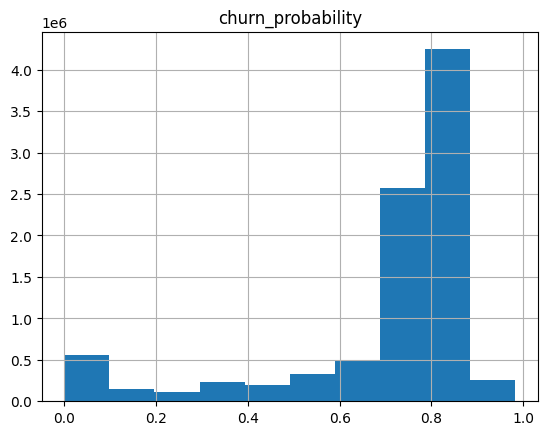

In [20]:
mdl_churn_predicted_df_filtered.hist()

<Axes: xlabel='churn_probability'>

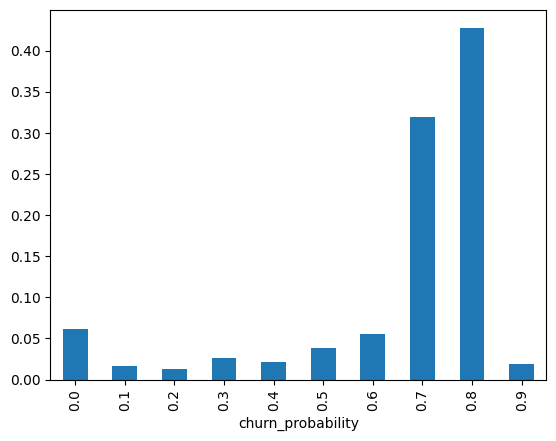

In [21]:
pd.cut(mdl_churn_predicted_df_filtered["churn_probability"], bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], labels=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]).value_counts(normalize=True).sort_index().plot(kind="bar")

# Analysis on May Campaign

In [45]:
may_df = pd.read_csv("202505_May_TargetList_MasterFile_churn_v3.csv", sep=",")

In [46]:
may_df.head()

,LastPhoneDigit,Nationality,Segment,LastPromoTaken,IsPromoHunter,IsChinesePMS,is40Kmultiple,DueOil,DuePMS,DueAirFilter,IsDueCabinFilter,IsDueTyres,IsDueBattery,IsDueBrakes,IsDueEngineFlush,IsDueSuspension,IsDueACServices,IsDueACRepair,IsDueHeadlightPolish,InvoicePromoCounts_12month,InvoiceCounts_12months,InvoicePromoCounts_total,InvoiceCounts_total,Last visit date,Mobile,PlateNumber,Make,Model,PreferredLanguage,Wave 2 Promo,Group,Mobile_Original,Churn_Probability
0,7,Saudi,Uncommitted,Special Promo Service Mineral,1,0,NaN,1,0,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,3.0,16.0,NaN,9.665060e+11,3006SVA,HONDA,ACCORD,AR,NaN,NaN,9.665060e+11,0.887494
1,3,Others,New Joiner,Null,0,0,NaN,0,1,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,NaN,9.665060e+11,4741ZKR,TOYOTA,RAV4,AR,Toyota PMS,NaN,9.665060e+11,0.410556
2,4,Saudi,Potential Loyal,Null,0,0,NaN,1,0,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,5.0,NaN,9.665060e+11,8945TZD,MAZDA,MAZDA CX-9,AR,NaN,NaN,9.665060e+11,0.440580
3,7,Saudi,Uncommitted,Null,0,0,NaN,1,0,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,5.0,NaN,9.665060e+11,4603RAA,TOYOTA,CAMRY,AR,NaN,NaN,9.665060e+11,0.865728
4,3,Others,Potential Loyal,Null,0,0,38041.0,1,0,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,9.0,31.0,NaN,9.665060e+11,8389EBD,TOYOTA,CAMRY,AR,NaN,NaN,9.665060e+11,0.811149


<Axes: >

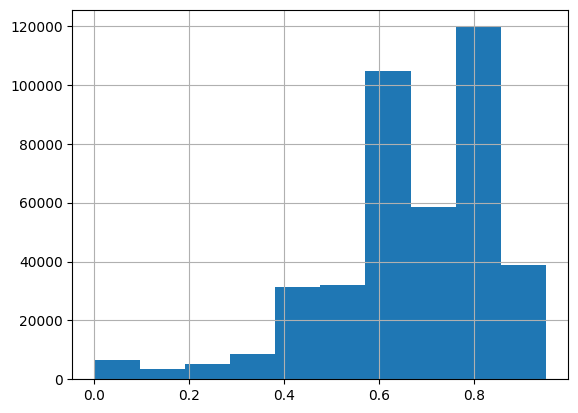

In [52]:
may_df["Churn_Probability"].hist()

<Axes: xlabel='Churn_Probability'>

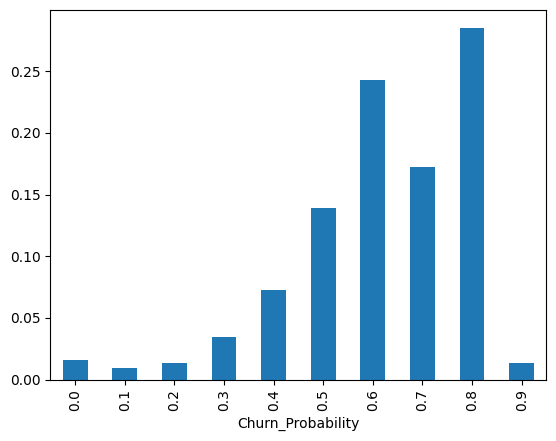

In [58]:
pd.cut(may_df["Churn_Probability"], bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], labels=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]).value_counts(normalize=True).sort_index().plot(kind="bar")